In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
def getStuff(s,l=0,h=10):
    msg = s + "/" + s + "_accs"
    for i in range(l,h):
        exec('df' + str(i) + ' = pd.read_csv(msg + str(i) + ".csv", index_col=0)')

    df = pd.DataFrame(data=[eval('df' + str(i) + '.iloc[1]') for i in range(l,h)])
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    median = df.median(axis=0)
    Q3 = df.quantile(0.75)
    Q1 = df.quantile(0.25)
    iqrO2 = (Q3-Q1)/2
    return mean, std, median, iqrO2

In [107]:
def getStuffTimes(s,l=0,h=10):
    msg = s + "/" + s + "_times"
    for i in range(l,h):
        exec('df' + str(i) + ' = pd.read_csv(msg + str(i) + ".csv", header=None)')
        #print(eval('df' + str(i)))

    df = pd.DataFrame(data=[eval('df' + str(i) + '[0]') for i in range(l,h)])
    df = df[df.columns[0:2]]
    print(df)
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    median = df.median(axis=0)
    Q3 = df.quantile(0.75)
    Q1 = df.quantile(0.25)
    iqrO2 = (Q3-Q1)/2
    return mean, std, median, iqrO2

In [108]:
augmean, augstd, augmedian, augiqr = getStuff("aug")
vanmean, vanstd, vanmedian, vaniqr = getStuff("nosym")
symmean, symstd, symmedian, symiqr = getStuff("blursym")
symaugmean, symaugstd, symaugmedian, symaugiqr = getStuff("symaug")

In [109]:
test0 = pd.read_csv("aug/aug_times0.csv",header=None)
test1 = pd.read_csv("aug/aug_times1.csv",header=None)
test2 = pd.read_csv("aug/aug_times2.csv",header=None)

In [110]:
test012 = pd.DataFrame([test0[0],test1[0],test2[0]])
test012

,0,1
0,33.373171,32.421674
0,32.200056,32.070464
0,32.047551,32.796275


In [111]:
test012[test012.columns[0:1]]

,0
0,33.373171
0,32.200056
0,32.047551


In [112]:
augmeant, augstdt, augmediant, augiqrt = getStuffTimes("aug")
vanmeant, vanstdt, vanmediant, vaniqrt = getStuffTimes("nosym")
symmeant, symstdt, symmediant, symiqrt = getStuffTimes("blursym")
symaugmeant, symaugstdt, symaugmediant, symaugiqrt = getStuffTimes("symaug")

           0          1
0  33.373171  32.421674
0  32.200056  32.070464
0  32.047551  32.796275
0  32.869732  33.250907
0  31.912251  31.959742
0  32.029228  32.596421
0  33.143018  33.627039
0  31.656718  31.556716
0  31.113771  31.362721
0  31.866622  31.773618
           0          1
0  30.901847  30.732372
0  29.787893  30.037601
0  31.147848  31.099470
0  29.630827  30.060437
0  33.457886  30.462129
0  30.900517  29.875972
0  29.744033  29.231915
0  28.924303  29.556955
0  29.547132  28.788689
0  32.760720  29.241932
           0          1
0  30.275231  49.470351
0  29.693480  49.087397
0  33.550421  50.392273
0  30.383103  50.311498
0  29.942675  50.038171
0  30.720871  50.102790
0  30.278638  49.144239
0  29.677240  48.998549
0  29.264534  48.853210
0  29.493223  49.474660
           0          1
0  31.329722  50.994711
0  30.241746  50.748126
0  30.148072  50.920770
0  30.303711  50.542537
0  30.868906  49.842688
0  29.871202  50.855471
0  30.713399  50.396692
0  30.324690  51

In [116]:
augmediant

0    32.038390
1    32.246069
dtype: float64

In [115]:
augiqrt

0    0.412142
1    0.463081
dtype: float64

In [117]:
symmediant

0    30.108953
1    49.472506
dtype: float64

In [118]:
symiqrt

0    0.337844
1    0.492514
dtype: float64

In [120]:
symaugmediant

0    30.369625
1    50.801798
dtype: float64

In [121]:
symaugiqrt

0    0.204697
1    0.208008
dtype: float64

In [122]:
vanmediant

0    30.344205
1    29.956787
dtype: float64

In [123]:
vaniqrt

0    0.713610
1    0.520509
dtype: float64

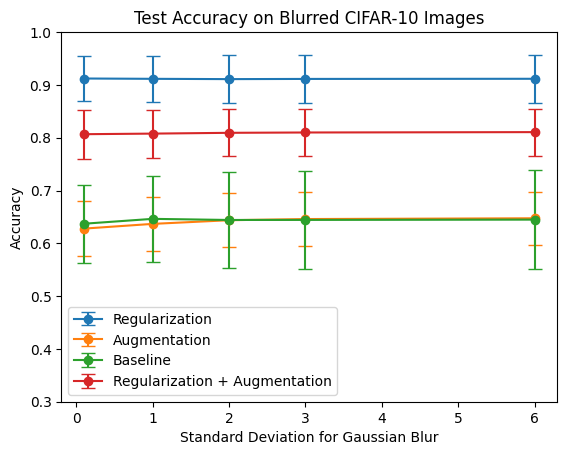

In [37]:
#plt.plot(x='x', y='y', yerr='y_error', kind='line', marker='o', capsize=4)
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symmean, yerr=symstd, fmt='-o', capsize=5, label="Regularization")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],augmean, yerr=augstd, fmt='-o', capsize=5, label="Augmentation")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],vanmean, yerr=vanstd, fmt='-o', capsize=5, label="Baseline")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symaugmean, yerr=symaugstd, fmt='-o', capsize=5, label="Regularization + Augmentation")
plt.title('Test Accuracy on Blurred CIFAR-10 Images')
plt.xlabel('Standard Deviation for Gaussian Blur')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0.3,1.0)
plt.savefig("CIFAR10_Blur.pdf")
plt.show()

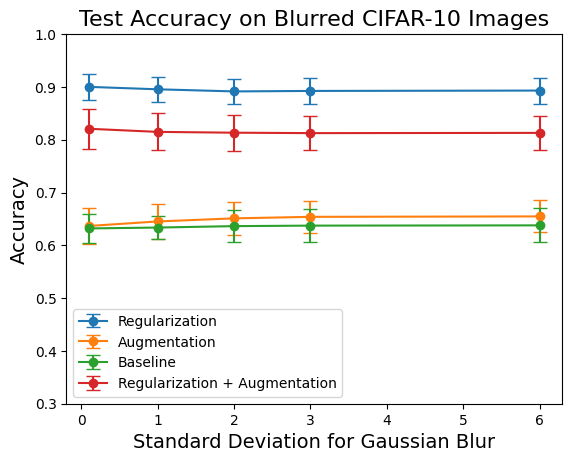

In [21]:
#plt.plot(x='x', y='y', yerr='y_error', kind='line', marker='o', capsize=4)
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symmedian, yerr=symiqr, fmt='-o', capsize=5, label="Regularization")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],augmedian, yerr=augiqr, fmt='-o', capsize=5, label="Augmentation")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],vanmedian, yerr=vaniqr, fmt='-o', capsize=5, label="Baseline")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symaugmedian, yerr=symaugiqr, fmt='-o', capsize=5, label="Regularization + Augmentation")
plt.title('Test Accuracy on Blurred CIFAR-10 Images', fontsize=16)
plt.xlabel('Standard Deviation for Gaussian Blur', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.ylim(0.3,1.0)
plt.savefig("CIFAR10_Blur-2.pdf")
plt.show()

In [6]:
augmean

0    0.62785
1    0.63681
2    0.64375
3    0.64598
4    0.64742
dtype: float64

In [7]:
augstd

0    0.051962
1    0.051487
2    0.051105
3    0.050461
4    0.050574
dtype: float64

In [8]:
symmean

0    0.91216
1    0.91155
2    0.91099
3    0.91135
4    0.91163
dtype: float64

In [9]:
symstd

0    0.043164
1    0.043835
2    0.045083
3    0.045362
4    0.045407
dtype: float64

In [10]:
vanmean

0    0.63709
1    0.64634
2    0.64422
3    0.64433
4    0.64488
dtype: float64

In [11]:
vanstd

0    0.073674
1    0.081710
2    0.091040
3    0.093057
4    0.094329
dtype: float64

In [12]:
augmedian

0    0.63665
1    0.64520
2    0.65105
3    0.65395
4    0.65475
dtype: float64

In [13]:
augiqr

0    0.033450
1    0.032413
2    0.031825
3    0.030350
4    0.030325
dtype: float64

In [14]:
symmedian

0    0.9001
1    0.8955
2    0.8915
3    0.8924
4    0.8931
dtype: float64

In [15]:
symiqr

0    0.025300
1    0.024200
2    0.023925
3    0.025050
4    0.024537
dtype: float64

In [16]:
vanmedian

0    0.63200
1    0.63365
2    0.63635
3    0.63730
4    0.63780
dtype: float64

In [17]:
vaniqr

0    0.027713
1    0.021913
2    0.029975
3    0.031788
4    0.032037
dtype: float64

In [18]:
symaugmedian

0    0.82075
1    0.81485
2    0.81330
3    0.81250
4    0.81295
dtype: float64

In [19]:
symaugiqr

0    0.038200
1    0.034825
2    0.033713
3    0.032700
4    0.032587
dtype: float64